In [1]:
import os

# GPU bellek parçalanmasını önlemek için kritik ayar (En başta olmalı)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import shutil
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             cohen_kappa_score, confusion_matrix, 
                             classification_report, roc_curve, auc, 
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize

# --- AYARLARIM ---
SEARCH_EPOCHS = 5    # Random Search için epoch sayısı
FULL_EPOCHS = 20     # Asıl eğitim (Full Training) epoch sayısı
PATIENCE = 3         # Erken durdurma (Early Stopping) sabrı
BATCH_SIZE = 32     
OUTPUT_DIR = 'resnet18' # Çıktı klasörümün adı

# Klasör varsa silelim, temiz bir sayfa açalım
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)

# Her seferinde aynı sonuçları almak için şans faktörünü sabitliyorum
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed) #  LR adaylarım hep aynı gelecek.
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sistem hazır, canavar çalışıyor... Cihaz: {device}")

Sistem hazır, canavar çalışıyor... Cihaz: cuda


In [2]:
# Veri seti yolum (Masaüstündeki klasör)
DATA_DIR = r'C:\Users\user\Desktop\DerinProjem\garbage-dataset'

# ResNet'in sevdiği standartlara göre resimleri hazırlıyorum
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print(f"\nVerileri şu yoldan okuyorum: {DATA_DIR}")
try:
    full_dataset = datasets.ImageFolder(DATA_DIR, transform=data_transforms)
    classes = full_dataset.classes
    print(f"Süper! Toplam {len(classes)} sınıf buldum: {classes}")
except Exception as e:
    print(f"HATA: Veri setini bulamadım! ({e})")
    
    full_dataset = datasets.FakeData(size=50, image_size=(3, 224, 224), num_classes=2, transform=data_transforms)
    classes = ['glass', 'paper']

# Veriyi bölüyorum: %70 Eğitim, %15 Doğrulama, %15 Test
targets = full_dataset.targets
train_idx, temp_idx = train_test_split(
    range(len(full_dataset)), test_size=0.3, stratify=targets, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=[targets[i] for i in temp_idx], random_state=42
)

# DataLoader'ları hazırlıyorum. Windows'ta num_workers=0 yapmak daha güvenli.
train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(Subset(full_dataset, test_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# --- SHAPE KONTROLÜ ---
# Bakalım modelin içine giren verinin şekli nasıl?
ornek_batch, ornek_label = next(iter(train_loader))
print(f"\n--- Shape Kontrolü (Gözümle göreyim) ---")
print(f"Batch Görüntü Boyutu: {ornek_batch.shape} --> (Batch Size, Kanal, Boy, En)")
print(f"Batch Etiket Boyutu:  {ornek_label.shape} --> (Batch Size)")


Verileri şu yoldan okuyorum: C:\Users\user\Desktop\DerinProjem\garbage-dataset
Süper! Toplam 10 sınıf buldum: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']

--- Shape Kontrolü (Gözümle göreyim) ---
Batch Görüntü Boyutu: torch.Size([32, 3, 224, 224]) --> (Batch Size, Kanal, Boy, En)
Batch Etiket Boyutu:  torch.Size([32]) --> (Batch Size)


In [3]:
def get_model(num_classes):
    # Güncel API ile ağırlıkları yüklüyorum, 'pretrained=True' eskidi artık.
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    
    # Son katmanı (fc) benim sınıf sayıma göre değiştiriyorum
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

# Top-K Accuracy hesaplayan fonksiyonum
def accuracy_topk(output, target, topk=(1,)):
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)
        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res.append(correct_k.mul_(100.0 / batch_size).item())
        return res

# Tek bir epoch eğitimi yapan fonksiyon
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / len(loader.dataset), 100. * correct / total

# Doğrulama (Validation) fonksiyonu
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return running_loss / len(loader.dataset), 100. * correct / total

In [4]:
# 10^-5 ile 10^-2 arasında rastgele 5 tane LR seçiyorum
# np.random.seed(42) sayesinde bu liste hep aynı olacak!
lr_candidates = [10**np.random.uniform(-5, -2) for _ in range(5)]
criterion = nn.CrossEntropyLoss()

best_lr = None
best_val_acc_search = 0.0

print(f"\n=== AŞAMA 1: Random Search Başlıyor ({SEARCH_EPOCHS} Epoch) ===")
print(f"Deneyeceğim LR değerleri: {[f'{lr:.6f}' for lr in lr_candidates]}")

for i, lr in enumerate(lr_candidates):
    print(f"\n>>> Deneme {i+1}/5 | LR: {lr:.6f}")
    
    # Bellek temizliği yapıyorum ki GPU şişmesin
    if 'temp_model' in locals():
        del temp_model
    torch.cuda.empty_cache()
    
    temp_model = get_model(len(classes))
    optimizer = optim.Adam(temp_model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SEARCH_EPOCHS)
    
    val_acc = 0
    for epoch in range(SEARCH_EPOCHS):
        train_loss, train_acc = train_one_epoch(temp_model, train_loader, criterion, optimizer)
        _, val_acc = validate(temp_model, val_loader, criterion)
        scheduler.step()
        print(f"   Ep {epoch+1}: Train Loss {train_loss:.3f} | Val Acc %{val_acc:.2f}")
    
    if val_acc > best_val_acc_search:
        best_val_acc_search = val_acc
        best_lr = lr
        print(f"   --> (!) Şu ana kadarki en iyi sonuç bu!")

print(f"\n>>> KAZANAN LEARNING RATE: {best_lr:.6f}")

# Temizlik 
del temp_model
torch.cuda.empty_cache()


=== AŞAMA 1: Random Search Başlıyor (5 Epoch) ===
Deneyeceğim LR değerleri: ['0.000133', '0.007114', '0.001570', '0.000625', '0.000029']

>>> Deneme 1/5 | LR: 0.000133


C:\Users\user\anaconda3\envs\pytorch_env\lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


   Ep 1: Train Loss 0.365 | Val Acc %94.47
   Ep 2: Train Loss 0.109 | Val Acc %94.70
   Ep 3: Train Loss 0.035 | Val Acc %96.09
   Ep 4: Train Loss 0.011 | Val Acc %96.66
   Ep 5: Train Loss 0.006 | Val Acc %96.66
   --> (!) Şu ana kadarki en iyi sonuç bu!

>>> Deneme 2/5 | LR: 0.007114
   Ep 1: Train Loss 2.072 | Val Acc %40.25
   Ep 2: Train Loss 1.706 | Val Acc %44.06
   Ep 3: Train Loss 1.455 | Val Acc %52.97
   Ep 4: Train Loss 1.277 | Val Acc %56.21
   Ep 5: Train Loss 1.093 | Val Acc %65.22

>>> Deneme 3/5 | LR: 0.001570
   Ep 1: Train Loss 0.956 | Val Acc %78.07
   Ep 2: Train Loss 0.589 | Val Acc %77.60
   Ep 3: Train Loss 0.368 | Val Acc %83.70
   Ep 4: Train Loss 0.200 | Val Acc %91.06
   Ep 5: Train Loss 0.078 | Val Acc %92.61

>>> Deneme 4/5 | LR: 0.000625
   Ep 1: Train Loss 0.599 | Val Acc %83.97
   Ep 2: Train Loss 0.332 | Val Acc %87.21
   Ep 3: Train Loss 0.181 | Val Acc %90.25
   Ep 4: Train Loss 0.071 | Val Acc %94.13
   Ep 5: Train Loss 0.020 | Val Acc %95.31

>>>

In [5]:
print(f"\n=== AŞAMA 2: Full Training ({FULL_EPOCHS} Epoch) ===")

# Kazanan LR ile ana modelimi oluşturuyorum
final_model = get_model(len(classes))
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FULL_EPOCHS)

# Grafikleri çizebilmek için her epoch'taki değerleri saklıyorum
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_full_acc = 0.0
patience_counter = 0

for epoch in range(FULL_EPOCHS):
    train_loss, train_acc = train_one_epoch(final_model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(final_model, val_loader, criterion)
    scheduler.step()
    
    # Listelere ekliyorum
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc / 100.0) # Yüzdeyi 0-1 arasına çekiyorum
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc / 100.0)
    
    print(f"Epoch {epoch+1}/{FULL_EPOCHS} | Val Acc: %{val_acc:.2f}")
    
    # Erken Durdurma (Early Stopping)
    if val_acc > best_full_acc:
        best_full_acc = val_acc
        torch.save(final_model.state_dict(), os.path.join(OUTPUT_DIR, 'best_model.pth'))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"   --> Sabrım taştı (Patience={PATIENCE}), daha fazla iyileşmiyor. Durduruyorum.")
            break

# En iyi ağırlıkları geri yüklüyorum
final_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth')))
print("Eğitim bitti, en iyi modeli yükledim.")


=== AŞAMA 2: Full Training (20 Epoch) ===
Epoch 1/20 | Val Acc: %94.06
Epoch 2/20 | Val Acc: %94.23
Epoch 3/20 | Val Acc: %94.10
Epoch 4/20 | Val Acc: %95.18
Epoch 5/20 | Val Acc: %94.64
Epoch 6/20 | Val Acc: %94.77
Epoch 7/20 | Val Acc: %94.64
   --> Sabrım taştı (Patience=3), daha fazla iyileşmiyor. Durduruyorum.
Eğitim bitti, en iyi modeli yükledim.


C:\Users\user\AppData\Local\Temp\ipykernel_22056\2888804567.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load(os.path.join(OUTPUT_D

In [6]:
print("\n=== Performans Analizi ve Raporlama ===")
final_model.eval()

y_true, y_pred, y_score = [], [], []
top1_sum, topk_sum = 0, 0
total_samples = 0

# Dinamik K değeri (Sınıf sayısı 5'ten azsa hata vermesin diye)
k_val = min(5, len(classes))
print(f"[Bilgi] Top-K Accuracy için K={k_val} kullanıyorum.")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = final_model(inputs)
        probs = torch.softmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(torch.max(probs, 1)[1].cpu().numpy())
        y_score.extend(probs.cpu().numpy())
        
        # Top-K Hesaplama
        res = accuracy_topk(outputs, labels, topk=(1, k_val))
        batch_num = labels.size(0)
        top1_sum += res[0] * batch_num / 100.0
        topk_sum += res[1] * batch_num / 100.0
        total_samples += batch_num

# Numpy dizilerine çevir
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

# Metrikleri hesapla
acc_top1 = (top1_sum / total_samples) * 100
acc_topk = (topk_sum / total_samples) * 100
kappa = cohen_kappa_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

# ROC AUC Hesaplama (Hata önleyici ile)
y_true_bin = label_binarize(y_true, classes=range(len(classes)))
try:
    if len(classes) > 2 and y_true_bin.shape[1] == y_score.shape[1]:
        roc_auc_macro = roc_auc_score(y_true_bin, y_score, average='macro', multi_class='ovr')
    else:
        roc_auc_macro = 0.0 # Binary veya eksik sınıf durumu
except:
    roc_auc_macro = 0.0

# --- TABLO 1: GENEL PERFORMANS ---
df_general = pd.DataFrame({
    'Model': ['ResNet18'],
    'Top-1 Accuracy': [f"%{acc_top1:.2f}"],
    f'Top-{k_val} Accuracy': [f"%{acc_topk:.2f}"],
    'Macro F1': [f"{macro_f1:.4f}"],
    'Weighted F1': [f"{weighted_f1:.4f}"],
    'ROC AUC': [f"{roc_auc_macro:.4f}"],
    'Cohen Kappa': [f"{kappa:.4f}"]
})
df_general.to_csv(os.path.join(OUTPUT_DIR, 'Genel_Performans.csv'), index=False)

# --- TABLO 2: SINIF BAZLI PERFORMANS ---
report_dict = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
df_classes = pd.DataFrame(report_dict).transpose().iloc[:-3, :3]
df_classes.to_csv(os.path.join(OUTPUT_DIR, 'Sinif_Bazli_Performans.csv'))
print("Tablolar CSV olarak kaydedildi.")


=== Performans Analizi ve Raporlama ===
[Bilgi] Top-K Accuracy için K=5 kullanıyorum.
Tablolar CSV olarak kaydedildi.


Grafikler hazırlanıyor... Lütfen bekleyin.


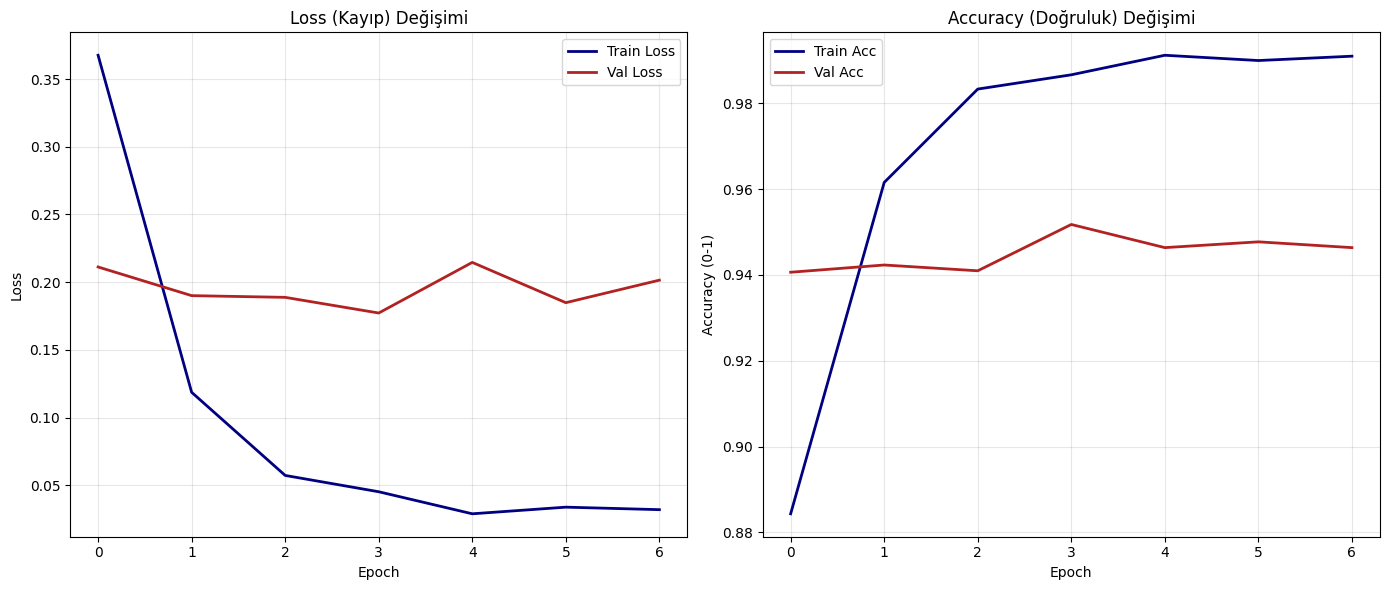

1. Eğitim grafiği çizildi. (Mavi ve Kırmızı çizgiler birbirine yakınsa iyidir)


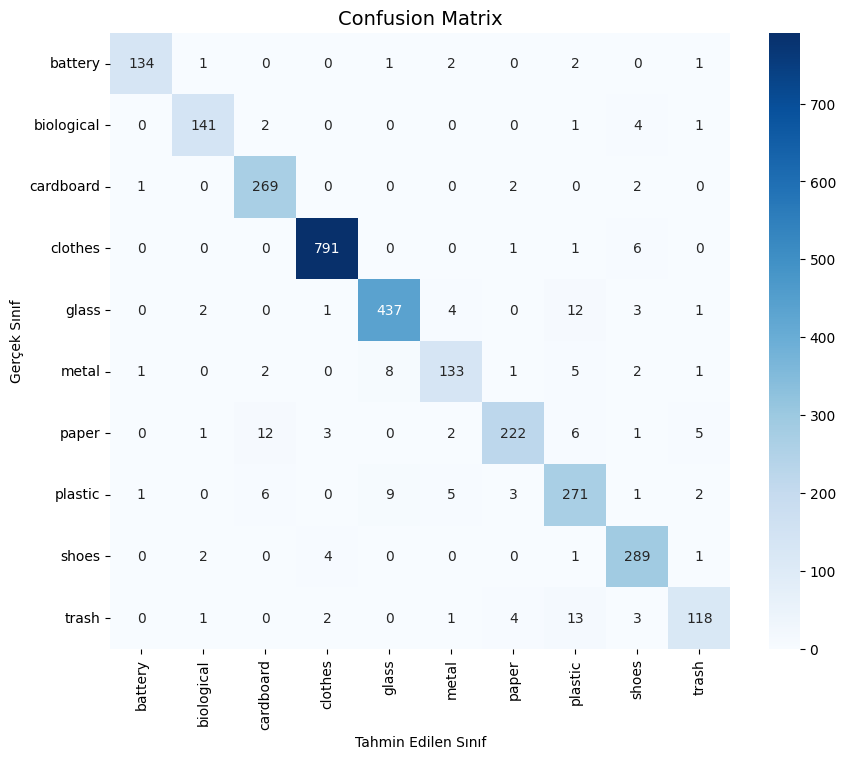

2. Confusion Matrix çizildi. (Koyu renkler köşegende toplanmalı)


C:\Users\user\AppData\Local\Temp\ipykernel_22056\565745717.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_classes.index, y=df_classes['f1-score'], palette='viridis')


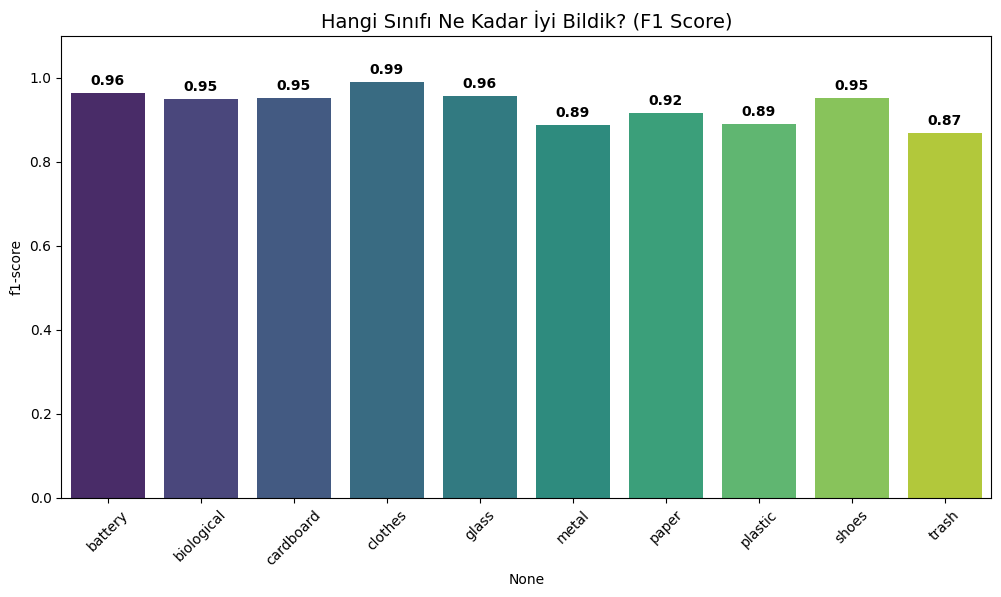

3. F1 Bar grafiği çizildi.


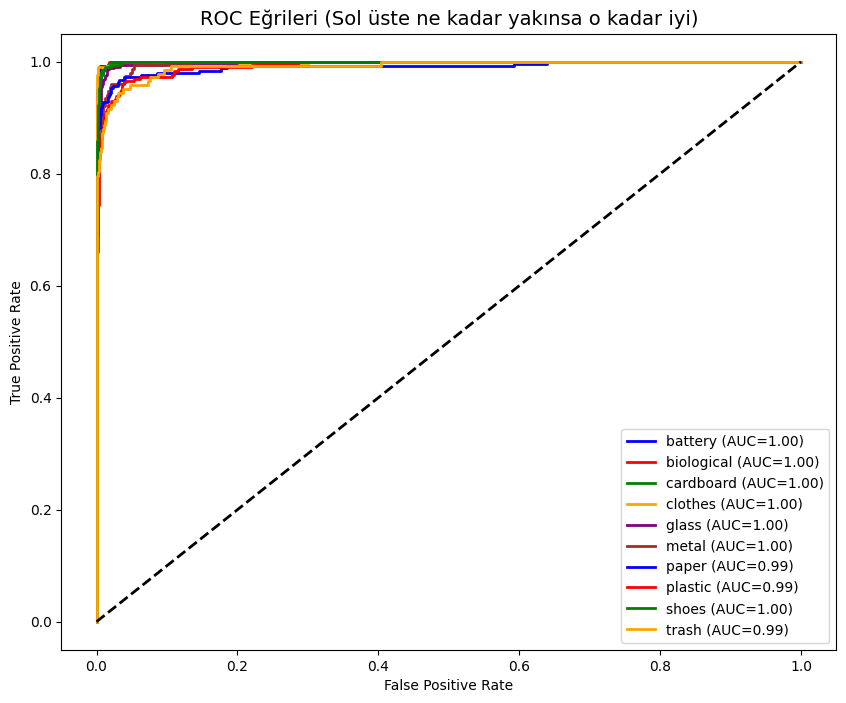

4. ROC Eğrileri çizildi.


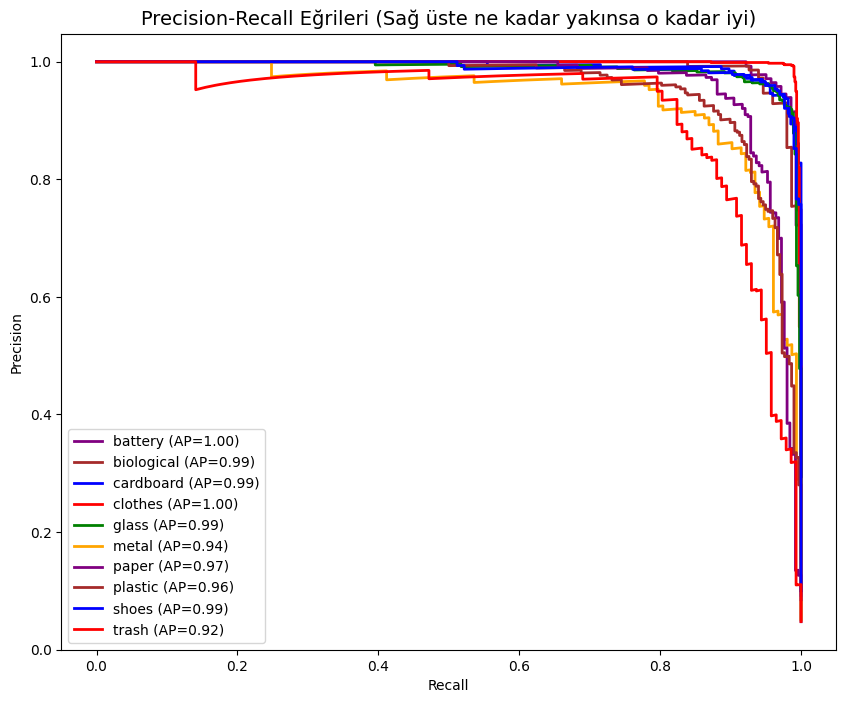

5. PR Eğrileri çizildi.
Son olarak modelin tahminlerinden örnekler geliyor...


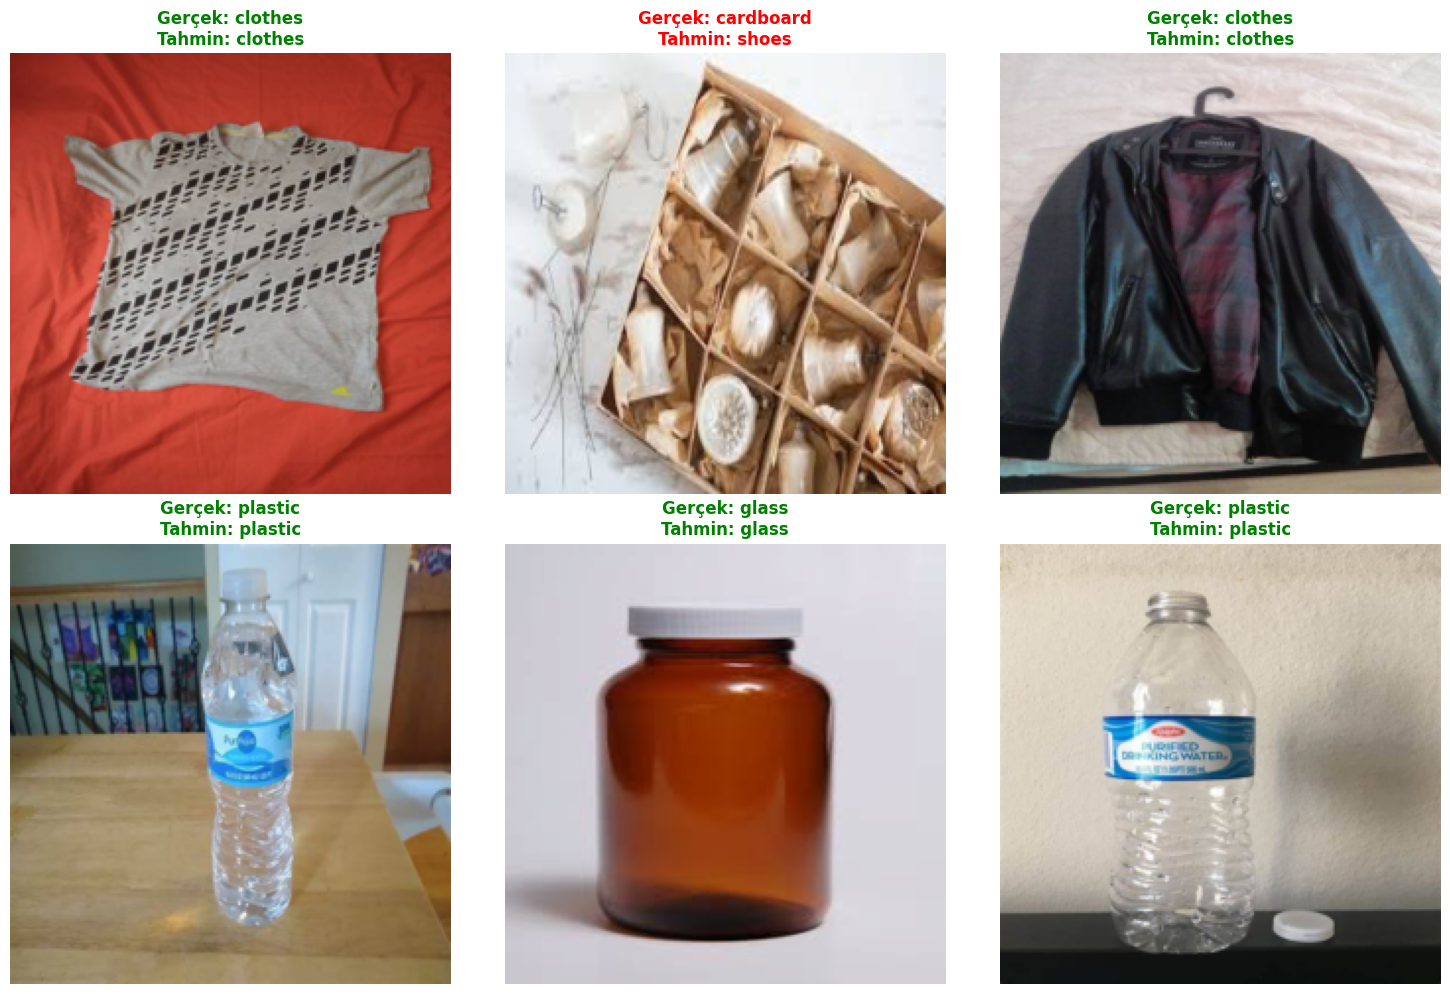

In [7]:
# --- 7. DETAYLI GRAFİKLER (GÖRSEL ŞÖLEN) ---
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

print("Grafikler hazırlanıyor... Lütfen bekleyin.")

# 1. Loss ve Accuracy Grafiği (Eğitim Süreci)
plt.figure(figsize=(14, 6))

# Sol taraf: Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='navy', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', color='firebrick', linewidth=2)
plt.title('Loss (Kayıp) Değişimi', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Sağ taraf: Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='navy', linewidth=2)
plt.plot(history['val_acc'], label='Val Acc', color='firebrick', linewidth=2)
plt.title('Accuracy (Doğruluk) Değişimi', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (0-1)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_Loss_Acc.png'))
plt.show() # <--- İşte bu komut ekrana basar!
print("1. Eğitim grafiği çizildi. (Mavi ve Kırmızı çizgiler birbirine yakınsa iyidir)")

# 2. Confusion Matrix (Karmaşıklık Matrisi)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_Confusion.png'))
plt.show()
print("2. Confusion Matrix çizildi. (Koyu renkler köşegende toplanmalı)")

# 3. Sınıf Bazlı F1 Skoru (Bar Grafik)
plt.figure(figsize=(12, 6))
sns.barplot(x=df_classes.index, y=df_classes['f1-score'], palette='viridis')
plt.title('Hangi Sınıfı Ne Kadar İyi Bildik? (F1 Score)', fontsize=14)
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
# Barların üzerine değerleri yazalım
for i, v in enumerate(df_classes['f1-score']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_F1_Bar.png'))
plt.show()
print("3. F1 Bar grafiği çizildi.")

# 4. ROC Eğrileri
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
for i, color in zip(range(len(classes)), colors):
    # Eğer sınıflar binary formatta ve tahminlerde varsa çiz
    if i < y_true_bin.shape[1]:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{classes[i]} (AUC={roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Şans çizgisi
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrileri (Sol üste ne kadar yakınsa o kadar iyi)', fontsize=14)
plt.legend(loc="lower right")
plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_ROC.png'))
plt.show()
print("4. ROC Eğrileri çizildi.")

# 5. Precision-Recall Eğrileri
plt.figure(figsize=(10, 8))
for i, color in zip(range(len(classes)), colors):
    if i < y_true_bin.shape[1]:
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_score[:, i])
        plt.plot(recall, precision, color=color, lw=2, label=f'{classes[i]} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Eğrileri (Sağ üste ne kadar yakınsa o kadar iyi)', fontsize=14)
plt.legend(loc="lower left")
plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_PR.png'))
plt.show()
print("5. PR Eğrileri çizildi.")

# 6. Tahmin Görselleri (Gözle Kontrol)
def visualize_preds(model, loader):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(15, 10))
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size(0)):
                if images_shown >= 6: break
                
                ax = plt.subplot(2, 3, images_shown+1)
                ax.axis('off')
                
                # Resmi eski haline getir (Denormalize et ki gözle görelim)
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                # ImageNet mean ve std değerleri
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                
                col = 'green' if preds[j] == labels[j] else 'red'
                baslik = f"Gerçek: {classes[labels[j]]}\nTahmin: {classes[preds[j]]}"
                
                ax.set_title(baslik, color=col, fontweight='bold', fontsize=12)
                ax.imshow(img)
                images_shown += 1
            if images_shown >= 6: break
            
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_Tahminler.png'))
    plt.show()

print("Son olarak modelin tahminlerinden örnekler geliyor...")
visualize_preds(final_model, test_loader)

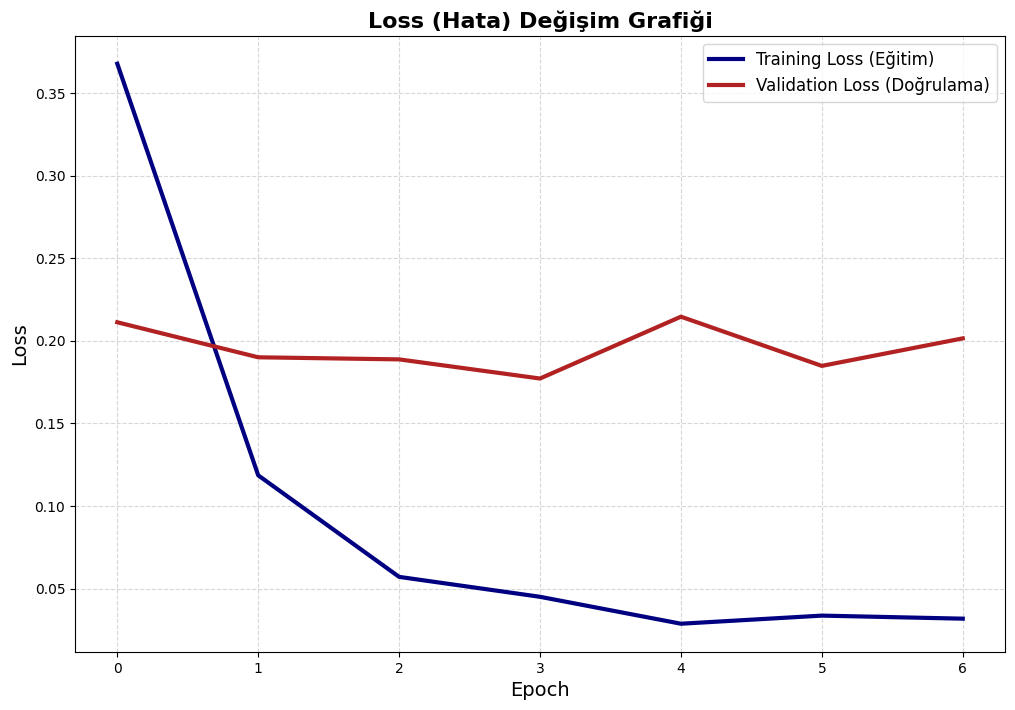

In [8]:
plt.figure(figsize=(12, 8))
plt.plot(history['train_loss'], label='Training Loss (Eğitim)', color='navy', linewidth=3)
plt.plot(history['val_loss'], label='Validation Loss (Doğrulama)', color='firebrick', linewidth=3)
plt.title('Loss (Hata) Değişim Grafiği', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

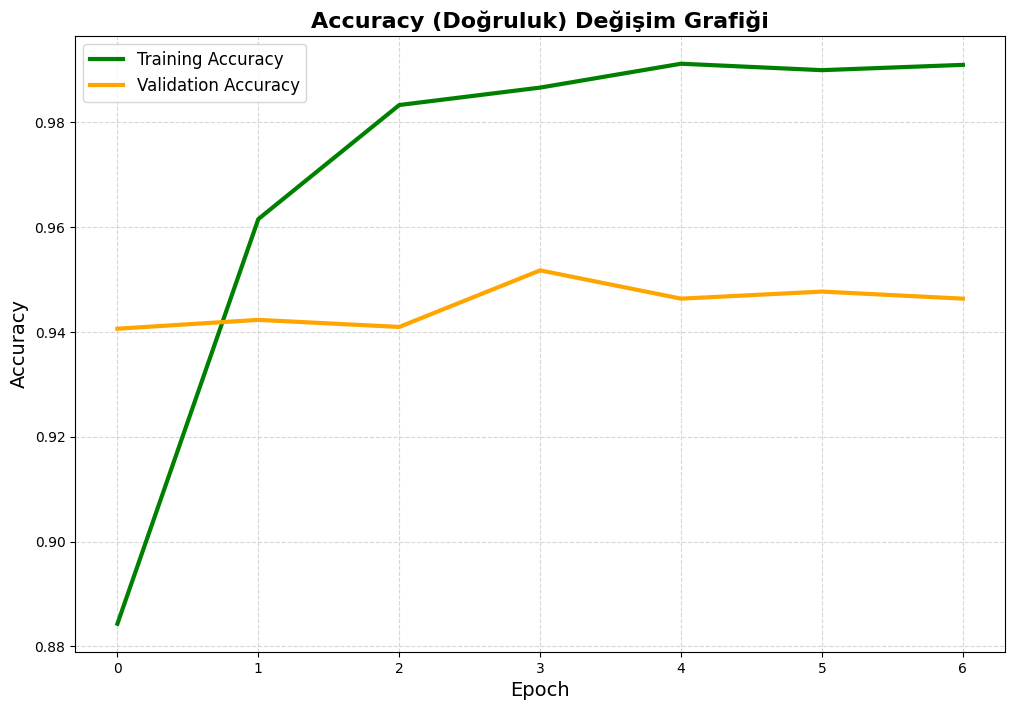

In [9]:
plt.figure(figsize=(12, 8))
plt.plot(history['train_acc'], label='Training Accuracy', color='green', linewidth=3)
plt.plot(history['val_acc'], label='Validation Accuracy', color='orange', linewidth=3)
plt.title('Accuracy (Doğruluk) Değişim Grafiği', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

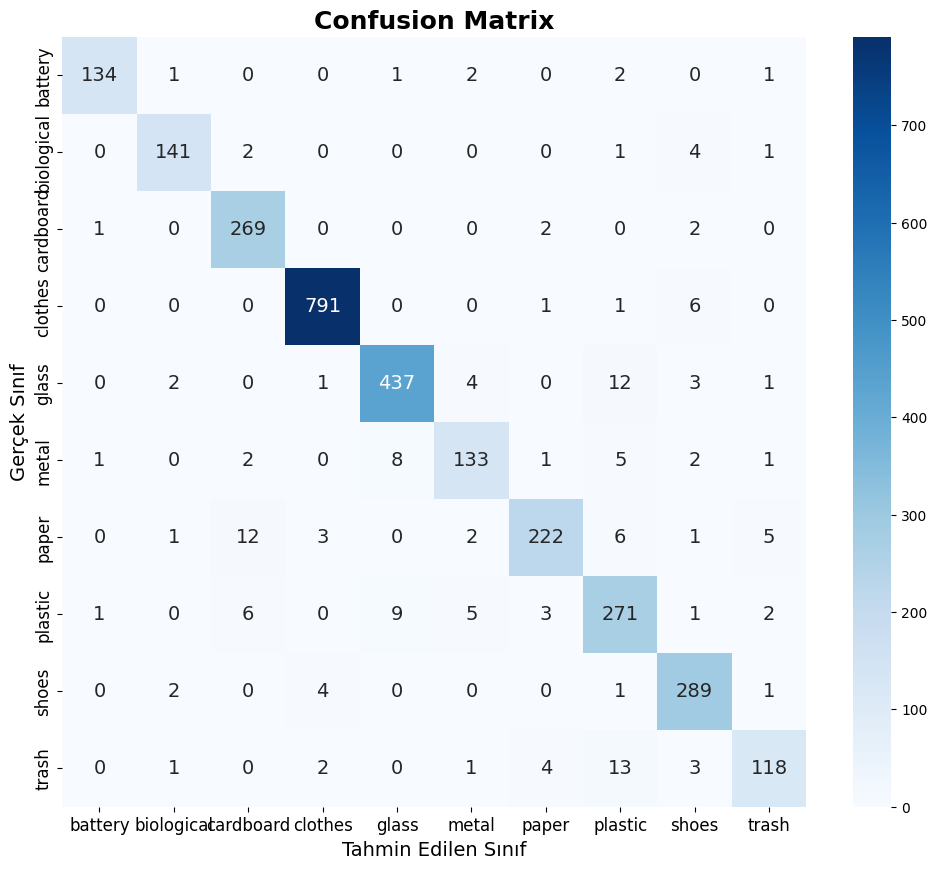

In [10]:
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14},
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')
plt.ylabel('Gerçek Sınıf', fontsize=14)
plt.xlabel('Tahmin Edilen Sınıf', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_22056\713446443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=df_classes.index, y=df_classes['f1-score'], palette='viridis')


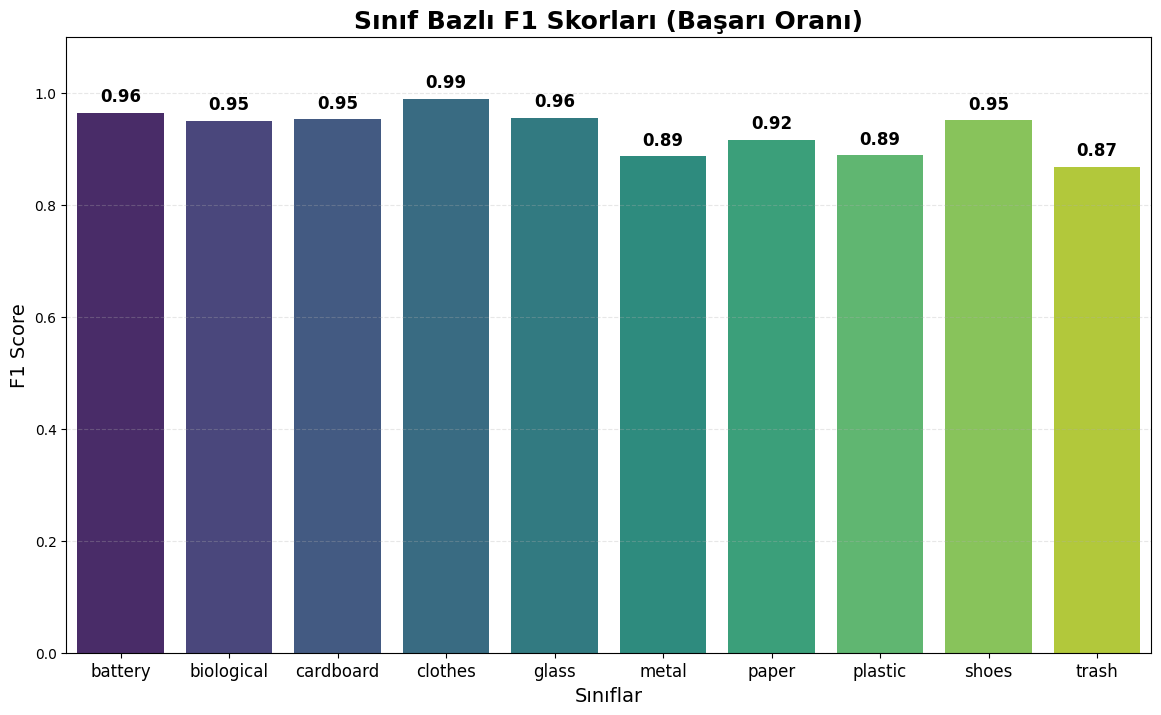

In [11]:
plt.figure(figsize=(14, 8))
barplot = sns.barplot(x=df_classes.index, y=df_classes['f1-score'], palette='viridis')

plt.title('Sınıf Bazlı F1 Skorları (Başarı Oranı)', fontsize=18, fontweight='bold')
plt.xlabel('Sınıflar', fontsize=14)
plt.ylabel('F1 Score', fontsize=14)
plt.ylim(0, 1.1)
plt.xticks(rotation=0, fontsize=12)

# Sütunların üzerine sayıları yazalım
for i, v in enumerate(df_classes['f1-score']):
    barplot.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

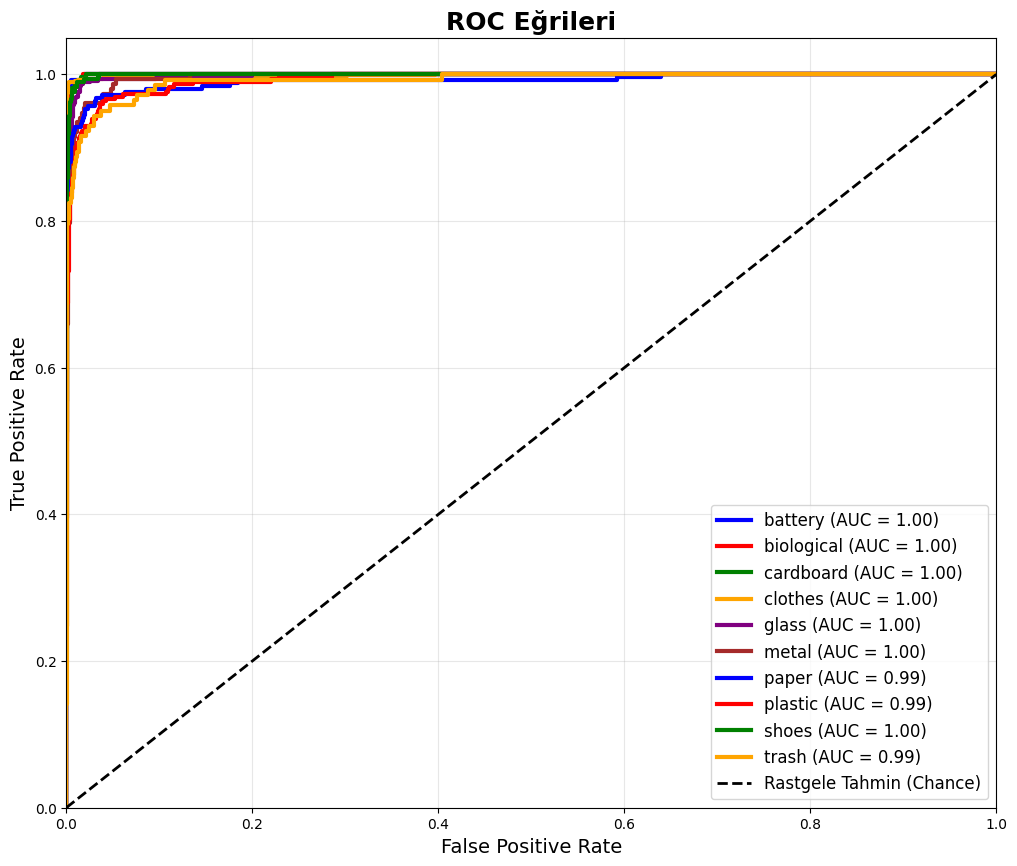

In [12]:
plt.figure(figsize=(12, 10))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])

for i, color in zip(range(len(classes)), colors):
    if i < y_true_bin.shape[1]:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=3, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Rastgele Tahmin (Chance)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Eğrileri', fontsize=18, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

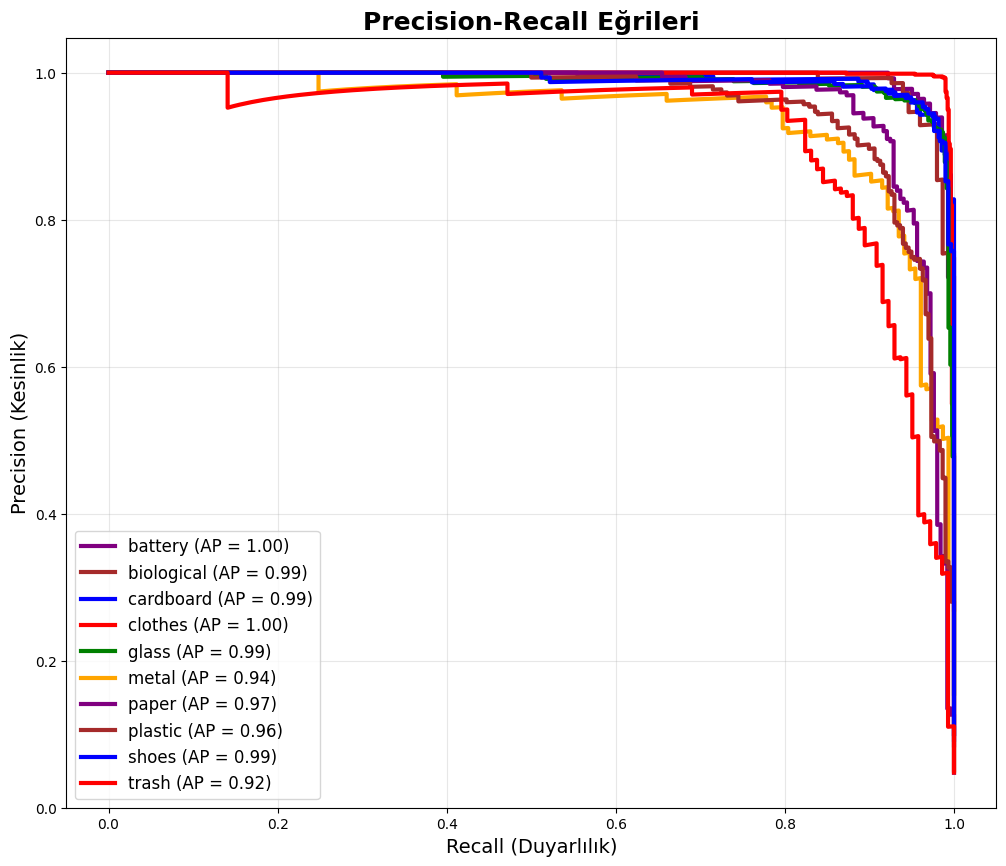

In [13]:
plt.figure(figsize=(12, 10))

for i, color in zip(range(len(classes)), colors):
    if i < y_true_bin.shape[1]:
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_score[:, i])
        plt.plot(recall, precision, color=color, lw=3, label=f'{classes[i]} (AP = {ap:.2f})')

plt.xlabel('Recall (Duyarlılık)', fontsize=14)
plt.ylabel('Precision (Kesinlik)', fontsize=14)
plt.title('Precision-Recall Eğrileri', fontsize=18, fontweight='bold')
plt.legend(loc="lower left", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

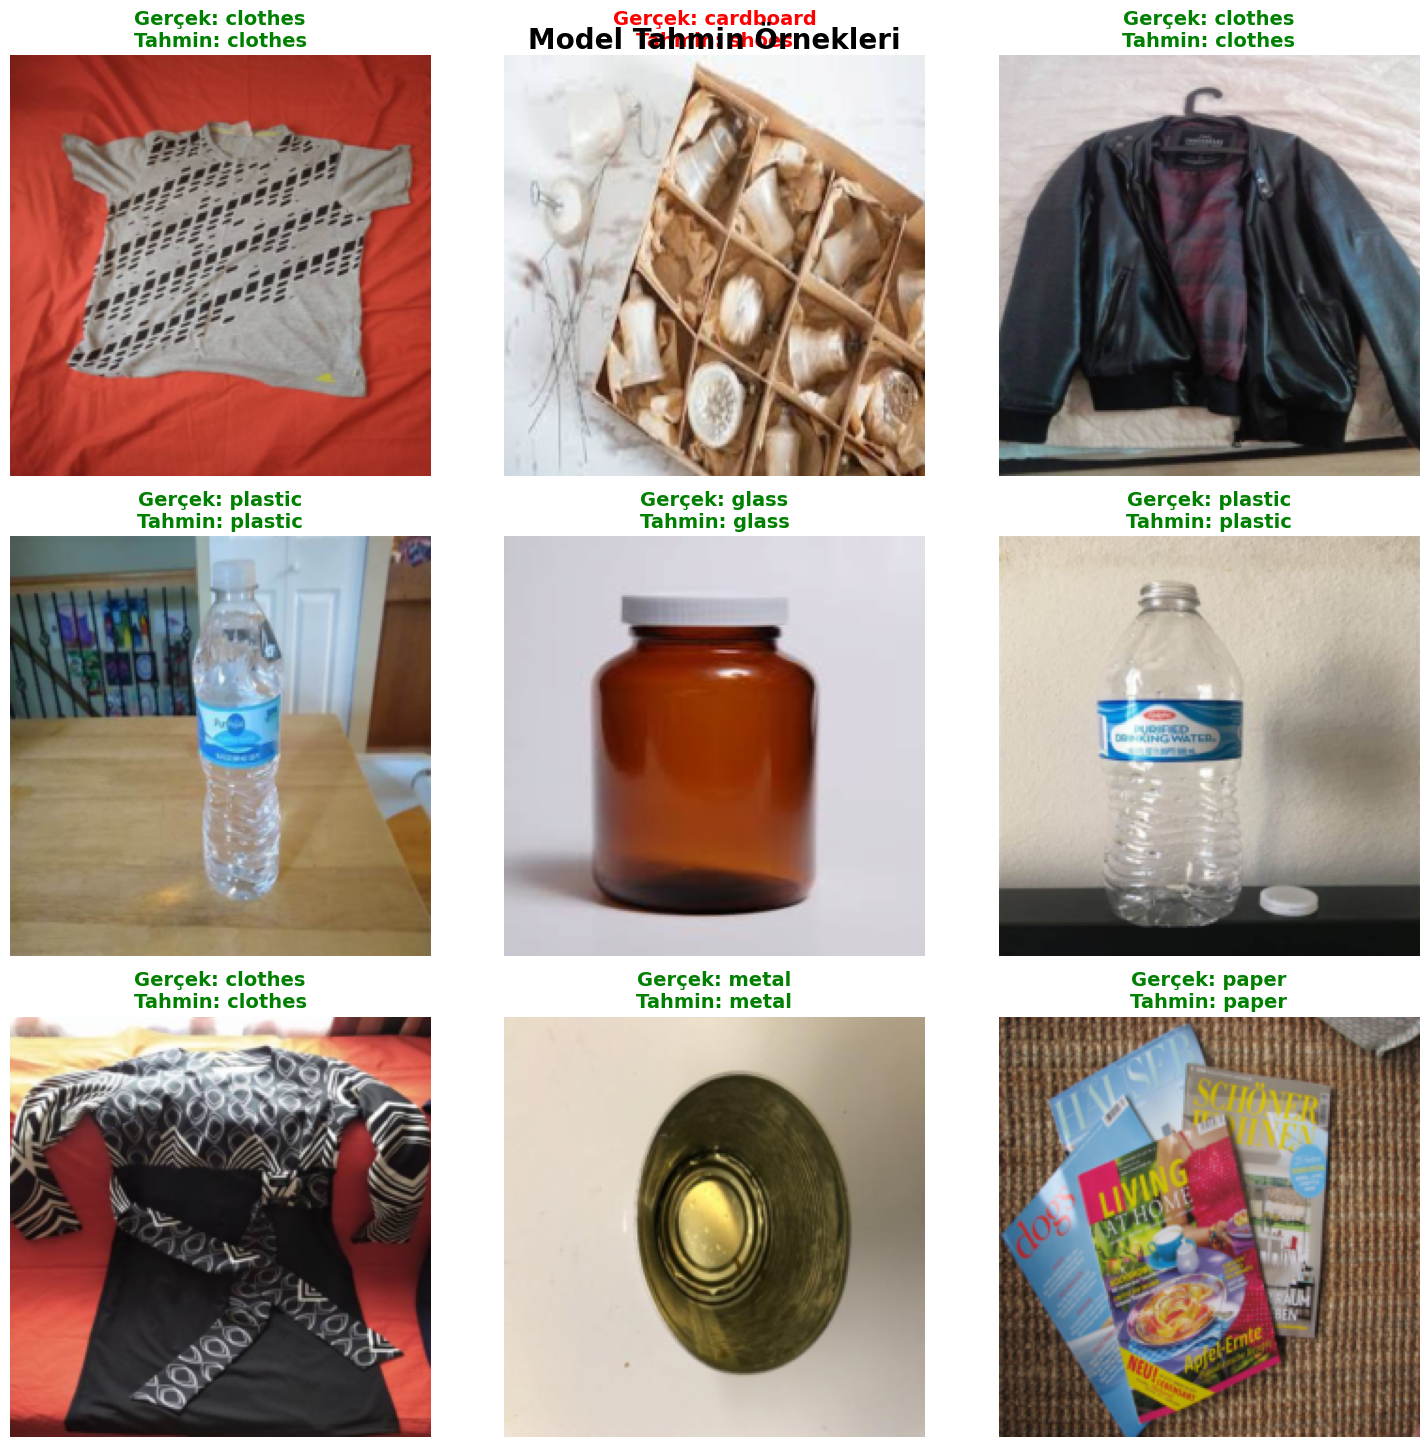

In [14]:
def visualize_large_preds(model, loader, count=9):
    model.eval()
    images_shown = 0
    
    # 3x3'lük büyük bir ızgara oluşturalım
    fig = plt.figure(figsize=(15, 15))
    plt.suptitle("Model Tahmin Örnekleri", fontsize=20, fontweight='bold', y=0.95)
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size(0)):
                if images_shown >= count: break
                
                ax = plt.subplot(3, 3, images_shown+1)
                
                # Resmi gösterilebilir hale getir
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = np.clip(std * img + mean, 0, 1)
                
                lbl_true = classes[labels[j]]
                lbl_pred = classes[preds[j]]
                
                # Doğruysa Yeşil, Yanlışsa Kırmızı Yazı
                col = 'green' if lbl_true == lbl_pred else 'red'
                
                ax.imshow(img)
                ax.set_title(f"Gerçek: {lbl_true}\nTahmin: {lbl_pred}", color=col, fontsize=14, fontweight='bold')
                ax.axis('off')
                
                images_shown += 1
            if images_shown >= count: break
    
    plt.tight_layout()
    plt.show()

visualize_large_preds(final_model, test_loader)

In [16]:
# 8. Paketleme

import shutil

shutil.make_archive('resnet18', 'zip', OUTPUT_DIR)

print(f"\n✅ TÜM İŞLEMLER BİTTİ! Grafikler ekrana basıldı ve '{OUTPUT_DIR}' içine kaydedildi.")

print(f"Zip dosyası hazır: {os.getcwd()}\\resnet18.zip")


✅ TÜM İŞLEMLER BİTTİ! Grafikler ekrana basıldı ve 'resnet18' içine kaydedildi.
Zip dosyası hazır: C:\Users\user\Desktop\DerinProjem\resnet18.zip
